TEST 5: TARGETED SWEEP - HUNTING THE D=2.0 ATTRACTOR

Running Targeted Sweep: T=25, Grid=30x30
Focusing on the downward slope of MAX_R=4 and 5...

  XI=0.8, MAX_R=4 -> D = 2.409
  XI=0.8, MAX_R=5 -> D = 2.384
  XI=0.9, MAX_R=4 -> D = 2.272
  XI=0.9, MAX_R=5 -> D = 2.243
  XI=1.0, MAX_R=4 -> D = 2.189
  XI=1.0, MAX_R=5 -> D = 2.192
  XI=1.1, MAX_R=4 -> D = 2.113
  XI=1.1, MAX_R=5 -> D = 2.073
  XI=1.2, MAX_R=4 -> D = 2.089
  XI=1.2, MAX_R=5 -> D = 2.006
  XI=1.3, MAX_R=4 -> D = 2.020
  XI=1.3, MAX_R=5 -> D = 1.990
  XI=1.4, MAX_R=4 -> D = 1.960
  XI=1.4, MAX_R=5 -> D = 1.897
  XI=1.5, MAX_R=4 -> D = 1.931
  XI=1.5, MAX_R=5 -> D = 1.805


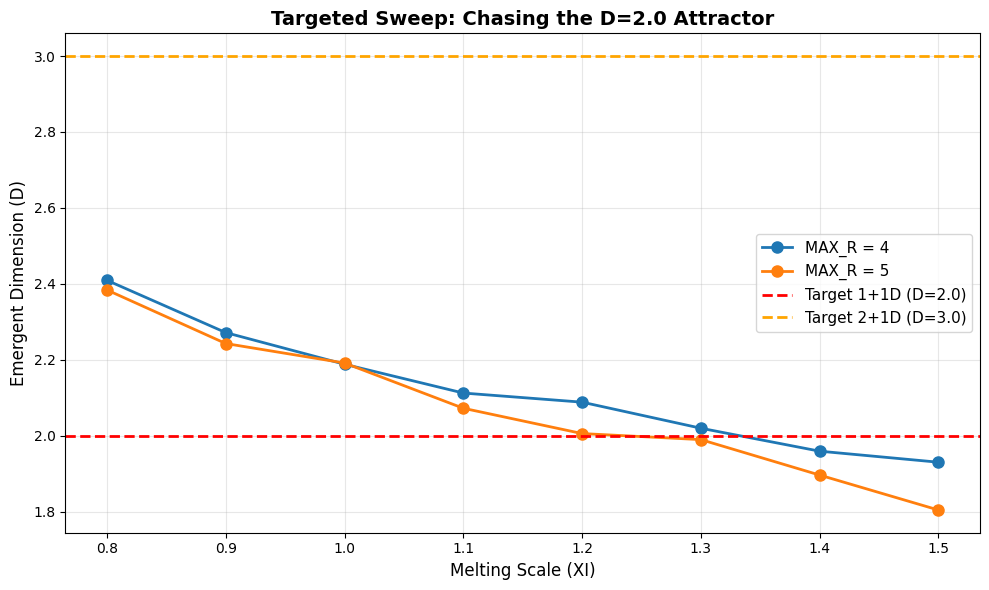


VERDICT
✓ SUCCESS: MAX_R=4 at XI=1.5 hit D ≈ 1.931!
~ OVERSHOT: MAX_R=5 dropped below 2.0 (D=1.805). The crossing is between XI=1.4 and 1.5.


In [1]:
# Avenue 7 Test 5 Option 2_Corrected
# Author: Néstor E. Ramos
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("TEST 5: TARGETED SWEEP - HUNTING THE D=2.0 ATTRACTOR")
print("=" * 80)

# Re-use the engine from the previous successful run
def generate_melting_causal_set(T, size, xi, max_r, p_min):
    longest_path = np.full((T, size, size), -1, dtype=np.int32)
    longest_path[0, size//2, size//2] = 0
    for t in range(1, T):
        for x in range(size):
            for y in range(size):
                max_parent_path = -1
                x_min, x_max = max(0, x - max_r), min(size, x + max_r + 1)
                y_min, y_max = max(0, y - max_r), min(size, y + max_r + 1)
                px_arr = np.arange(x_min, x_max)
                py_arr = np.arange(y_min, y_max)
                PX, PY = np.meshgrid(px_arr, py_arr)
                dist = np.sqrt((x - PX)**2 + (y - PY)**2)
                parent_paths = longest_path[t-1, y_min:y_max, x_min:x_max]
                valid_mask = parent_paths != -1
                if np.any(valid_mask):
                    valid_dist = dist[valid_mask]
                    valid_paths = parent_paths[valid_mask]
                    probs = np.exp(-valid_dist / xi)
                    probs[valid_dist < 1.5] = np.maximum(probs[valid_dist < 1.5], p_min)
                    connections = np.random.rand(len(probs)) < probs
                    if np.any(connections):
                        max_parent_path = np.max(valid_paths[connections])
                if max_parent_path != -1:
                    longest_path[t, x, y] = max_parent_path + 1
    return longest_path

def measure_dimension(longest_path):
    T, size, _ = longest_path.shape
    max_L = np.max(longest_path)
    if max_L < 3: return 0.0
    V_L = np.zeros(max_L + 1, dtype=np.int64)
    for L in range(max_L + 1): V_L[L] = np.sum(longest_path == L)
    cum_V = np.cumsum(V_L)
    valid = (np.arange(max_L + 1) > 1) & (cum_V > 0)
    L_vals = np.arange(max_L + 1)[valid]
    V_vals = cum_V[valid]
    if len(L_vals) > 2:
        slope, _ = np.polyfit(np.log(L_vals), np.log(V_vals), 1)
        return slope
    return 0.0

# TARGETED PARAMETERS based on your graph
# We focus on MAX_R = 4 and 5, and push XI higher to follow the downward slope
XI_TARGETS = [0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
R_TARGETS = [4, 5]
T_SWEEP = 25
SIZE_SWEEP = 30
P_MIN = 0.8

print(f"\nRunning Targeted Sweep: T={T_SWEEP}, Grid={SIZE_SWEEP}x{SIZE_SWEEP}")
print("Focusing on the downward slope of MAX_R=4 and 5...\n")

results = {r: [] for r in R_TARGETS}

for xi in XI_TARGETS:
    for r in R_TARGETS:
        dims = []
        for _ in range(3): # Average 3 runs for stability
            lp = generate_melting_causal_set(T_SWEEP, SIZE_SWEEP, xi, r, P_MIN)
            d = measure_dimension(lp)
            if d > 0: dims.append(d)
        avg_d = np.mean(dims) if dims else 0.0
        results[r].append(avg_d)
        print(f"  XI={xi:.1f}, MAX_R={r} -> D = {avg_d:.3f}")

# VISUALIZATION
fig, ax = plt.subplots(figsize=(10, 6))
for r in R_TARGETS:
    ax.plot(XI_TARGETS, results[r], 'o-', linewidth=2, markersize=8, label=f'MAX_R = {r}')

ax.axhline(y=2.0, color='red', linestyle='--', linewidth=2, label='Target 1+1D (D=2.0)')
ax.axhline(y=3.0, color='orange', linestyle='--', linewidth=2, label='Target 2+1D (D=3.0)')
ax.set_xlabel('Melting Scale (XI)', fontsize=12)
ax.set_ylabel('Emergent Dimension (D)', fontsize=12)
ax.set_title('Targeted Sweep: Chasing the D=2.0 Attractor', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('test5_targeted_sweep_D2.png', dpi=300)
plt.show()

print("\n" + "=" * 80)
print("VERDICT")
print("=" * 80)
# Check if we crossed 2.0
for r in R_TARGETS:
    last_d = results[r][-1]
    if 1.9 <= last_d <= 2.1:
        print(f"✓ SUCCESS: MAX_R={r} at XI={XI_TARGETS[-1]} hit D ≈ {last_d:.3f}!")
    elif last_d < 2.0:
        print(f"~ OVERSHOT: MAX_R={r} dropped below 2.0 (D={last_d:.3f}). The crossing is between XI={XI_TARGETS[-2]} and {XI_TARGETS[-1]}.")
    else:
        print(f"→ APPROACHING: MAX_R={r} is at D={last_d:.3f}. Need higher XI.")